# **Tutorial:** Custom YOLO Object Detection with RoboFlow

In this tutorial, you'll learn how to create a custom YOLO object detection model using your own classes and annotations with RoboFlow.

### **Step 1: Install Required Dependencies**

In [1]:
%pip install --upgrade ultralytics
%pip install opencv-python
%pip install roboflow
%pip install matplotlib
%pip install numpy==1.26.4 --force-reinstall

  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached numpy-2.4.3-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ----------------- ---------------------- 0.5/1.2 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 1.2/1.2 MB 5.0 MB/s  0:00:00
Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached numpy-2.4.3-cp311-cp311-win_amd64.whl (12.6 MB)
   ---------------------------------------- 0.0/824.0 kB ? eta -:--:--
   ---------------------------------------- 824.0/824.0 kB 4.5 MB/s  0:00:00
   ---------------------------------------- 0.0/47.0 MB ? eta -:--:--
    --------------------------------------- 1.0/47.0 MB 5.6 MB/s eta 0:00:09
   -- ------------------------------------- 3.1/47.0 MB 7.7 MB/s eta 0:00:06
   ---- 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-learn 1.3.2 requires numpy<2.0,>=1.17.3, but you have numpy 2.4.3 which is incompatible.
tensorflow 2.21.0 requires keras>=3.12.0, but you have keras 2.15.0 which is incompatible.
tensorflow 2.21.0 requires ml_dtypes<1.0.0,>=0.5.1, but you have ml-dtypes 0.2.0 which is incompatible.
tensorflow 2.21.0 requires protobuf<8.0.0,>=6.31.1, but you have protobuf 4.25.8 which is incompatible.


Note: you may need to restart the kernel to use updated packages.


   ---------------------------------------- 0.0/38.8 MB ? eta -:--:--
   - -------------------------------------- 1.3/38.8 MB 6.1 MB/s eta 0:00:07
   --- ------------------------------------ 3.4/38.8 MB 8.4 MB/s eta 0:00:05
   ------ --------------------------------- 6.3/38.8 MB 10.2 MB/s eta 0:00:04
   -------- ------------------------------- 7.9/38.8 MB 10.6 MB/s eta 0:00:03
   -------- ------------------------------- 8.7/38.8 MB 8.4 MB/s eta 0:00:04
   --------- ------------------------------ 9.4/38.8 MB 7.5 MB/s eta 0:00:04
   ------------ --------------------------- 12.1/38.8 MB 8.2 MB/s eta 0:00:04
   ---------------- ----------------------- 15.7/38.8 MB 9.3 MB/s eta 0:00:03
   ------------------ --------------------- 18.4/38.8 MB 9.6 MB/s eta 0:00:03
   -------------------- ------------------- 20.2/38.8 MB 9.4 MB/s eta 0:00:02
   ---------------------- ----------------- 22.0/38.8 MB 9.3 MB/s eta 0:00:02
   ------------------------- -------------- 24.6/38.8 MB 9.6 MB/s eta 0:00:0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.21.0 requires keras>=3.12.0, but you have keras 2.15.0 which is incompatible.
tensorflow 2.21.0 requires ml_dtypes<1.0.0,>=0.5.1, but you have ml-dtypes 0.2.0 which is incompatible.
tensorflow 2.21.0 requires protobuf<8.0.0,>=6.31.1, but you have protobuf 4.25.8 which is incompatible.


Note: you may need to restart the kernel to use updated packages.


  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.3
    Uninstalling numpy-2.4.3:
      Successfully uninstalled numpy-2.4.3
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tensorflow 2.21.0 requires keras>=3.12.0, but you have keras 2.15.0 which is incompatible.
tensorflow 2.21.0 requires ml_dtypes<1.0.0,>=0.5.1, but you have ml-dtypes 0.2.0 which is incompatible.
tensorflow 2.21.0 requires protobuf<8.0.0,>=6.31.1, but you have protobuf 4.25.8 which is incompatible.


### **Step 2: Import Required Libraries**

In [2]:
import cv2
from roboflow import Roboflow
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np
import os
from IPython.display import Image, display

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\cyanezru\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### **Step 3: Set Up RoboFlow Account**

1. Go to RoboFlow and create a free account
2. Create a new project and select "Object Detection" as project type
3. Choose "YOLOv26" as the model format

### **Step 4: Upload and Annotate Your Images**

#### Using RoboFlow Web Interface:

1. Click "Upload" to add your images
2. Use the annotation tool to draw bounding boxes around objects
3. Assign the correct class labels to each bounding box
4. Apply preprocessing and augmentation as needed

### **Step 5. Download your Custom your Dataset**

1. In RoboFlow, go to your project dashboard
2. Click "Generate" to create a dataset version
3. Apply any desired augmentations
4. Click "Export" and select "YOLOv**x**" format (**x** the version you are using)
5. Copy the download code

In [3]:
# Initialize RoboFlow (you'll need your API key)

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="JveMfT08UpOOztjKycz2")
project = rf.workspace("carlosyanezs-workspace").project("clase3_grupo3")
version = project.version(1)
dataset = version.download("yolo26")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Clase3_Grupo3-1 in yolo26:: 100%|██████████| 119/119 [00:00<00:00, 272.80it/s]


### **Step 6: Train Your Custom YOLO Model**

In [4]:
# Load the YOLO model with custom configuration
model = YOLO('yolo26n.pt')  # Using nano version as base

# Train the model on your custom dataset
results = model.train(
    data=f'{dataset.location}/data.yaml',  # Path to dataset config
    epochs=20,  # Number of training epochs
    imgsz=640,  # Image size
    batch=16,   # Batch size
    name='custom_yolo_model'  # Name for the training run
)

Ultralytics 8.4.26  Python-3.11.9 torch-2.11.0+cpu CPU (13th Gen Intel Core i7-1355U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\cyanezru\OneDrive - NTT DATA EMEAL\Documentos\Repositories\Vision-por-computador-MIA-B---Grupo-3\Clase_3\Clase3_Grupo3-1/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cu

### **Step 7: Evaluate Your Model**

In [5]:
# Evaluate model performance
metrics = model.val()  # Validate the model
print(f"mAP50-95: {metrics.box.map}")
print(f"mAP50: {metrics.box.map50}")

# Show some validation results
!yolo task=detect mode=val model=runs/detect/custom_yolo_model/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.4.26  Python-3.11.9 torch-2.11.0+cpu CPU (13th Gen Intel Core i7-1355U)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.20.0 ms, read: 72.834.7 MB/s, size: 36.4 KB)
val: Scanning C:\Users\cyanezru\OneDrive - NTT DATA EMEAL\Documentos\Repositories\Vision-por-computador-MIA-B---Grupo-3\Clase_3\Clase3_Grupo3-1\valid\labels.cache... 21 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 21/21  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.1s/it 2.3s5.9s
                   all         21         21    0.00497      0.938      0.185      0.137
              oximeter          8          8    0.00147      0.875      0.158      0.122
      pencil_sharpener         13         13    0.00846          1      0.211      0.151
Speed: 2.8ms preprocess, 94.6ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to C:\Users\cyanezru\OneDri

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\cyanezru\AppData\Local\Programs\Python\Python311\Scripts\yolo.exe\__main__.py", line 5, in <module>
  File "c:\Users\cyanezru\AppData\Local\Programs\Python\Python311\Lib\site-packages\ultralytics\cfg\__init__.py", line 907, in entrypoint
    check_dict_alignment(full_args_dict, {a: ""})
  File "c:\Users\cyanezru\AppData\Local\Programs\Python\Python311\Lib\site-packages\ultralytics\cfg\__init__.py", line 506, in check_dict_alignment
    raise SyntaxError(string + CLI_HELP_MSG) from e
SyntaxError: '-' is not a valid YOLO argument. 

    Arguments received: ['yolo', 'task=detect', 'mode=val', 'model=runs/detect/custom_yolo_model/weights/best.pt', 'data=c:\\Users\\cyanezru\\OneDrive', '-', 'NTT', 'DATA', 'EMEAL\\Documentos\\Repositories\\Vision-por-computador-MIA-B---Grupo-3\\Clase_3\\Clase3_Grupo3-1/data.yaml']. Ultralytics 'yolo' com

### **Step 8: Test Your Custom Model on an Image**


image 1/1 C:\Users\cyanezru\OneDrive - NTT DATA EMEAL\Documentos\Repositories\Vision-por-computador-MIA-B---Grupo-3\Clase_3\dataset\oximeter.jpg: 640x640 (no detections), 264.7ms
Speed: 18.7ms preprocess, 264.7ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)


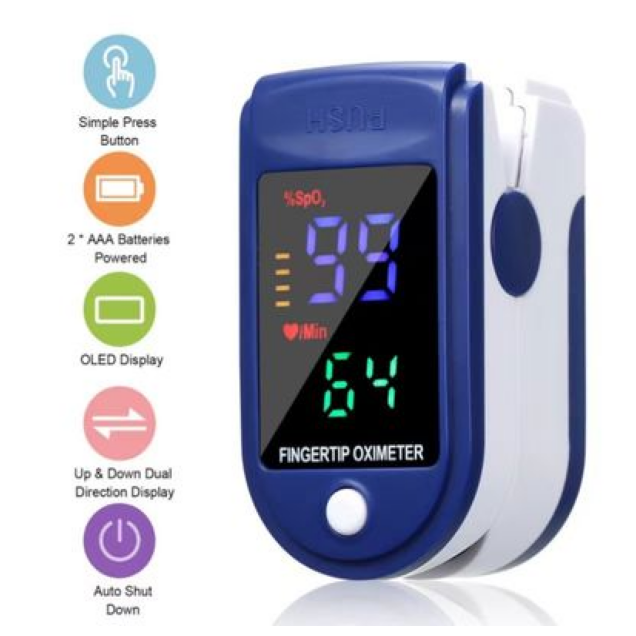

In [12]:
# Load your custom trained model
custom_model = YOLO(r'C:\Users\cyanezru\OneDrive - NTT DATA EMEAL\Documentos\Repositories\Vision-por-computador-MIA-B---Grupo-3\Clase_3\runs\detect\custom_yolo_model\weights\best.pt')

# Test on a sample image
results = custom_model(r'C:\Users\cyanezru\OneDrive - NTT DATA EMEAL\Documentos\Repositories\Vision-por-computador-MIA-B---Grupo-3\Clase_3\dataset\oximeter.jpg', conf=0.25)

# Display results
%matplotlib inline
for result in results:
    img = result.plot()  # Plot detections
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

### **Step 9: Test Your Custom Model on Video**

In [ ]:
# Write your code here..



## **Activity: Create Your Custom Detector**

1. **Create a RoboFlow account** and set up a new project
2. **Upload at least 25 images** of your custom objects (at least 2)
3. **Annotate all images** with bounding boxes and class labels
4. **Train a YOLO model** on your custom dataset
5. **Test your model** on new images and evaluate its performance
6. **Implement real-time detection** with your custom classes

## **Grading Rubric:**

| **Criteria** | **Points** | **Description** |
|-------------|-----------|----------------|
| **1. Dataset Creation** | 4 | Successfully creates and annotates a custom dataset with at least 25 images and multiple classes in RoboFlow. |
| **2. Model Training** | 1 | Properly trains a YOLOv8 model on the custom dataset with appropriate hyperparameters. |
| **3. Model Evaluation** | 1 | Evaluates model performance with appropriate metrics and provides analysis of results. |
| **4. Custom Detection** | 3 | Implements real-time detection with custom classes and displays results correctly. You have to use video from your webcam, no images or saved videos allowed. |
| **5. Documentation** | 1 | Provides clear documentation of the process, including dataset details and model performance. |

**Total: 10 points**

## **Tips for Success:**

- **Quality over quantity**: Well-annotated images are more important than many poorly annotated ones
- **Class balance**: Try to have a similar number of examples for each class
- **Variety**: Include different angles, lighting conditions, and backgrounds
- **Augmentation**: Use RoboFlow's augmentation features to expand your dataset

<p style="text-align: right; font-size:14px; color:gray;">
<b>Prepared by:</b><br>
Manuel Eugenio Morocho-Cayamcela
</p>